In [4]:
print("Hello Scaler Team,","\n")
print("I am working on Bussiness case : Aerofit - Descriptive Statistics & Probability")

Hello Scaler Team, 

I am working on Bussiness case : Aerofit - Descriptive Statistics & Probability


In [5]:
'''Problem Statement:
 Aerofit Treadmill Customer Analysis - To identify the characteristics of the target audience for each type of treadmill 
 offered by the company, to provide a better recommendation of the treadmills to the new customers 
 '''

'Problem Statement:\n Aerofit Treadmill Customer Analysis - To identify the characteristics of the target audience for each type of treadmill \n offered by the company, to provide a better recommendation of the treadmills to the new customers \n '

In [6]:
# Objective: 
# To identify customer characteristics for each treadmill model and create detailed customer profiles that will help Aerofit 
    # provide better product recommendations to new customers based on their demographics and fitness levels.
# 1.Analyze customer data to find patterns between customer attributes and the treadmill models they purchase
# 2.Use descriptive statistics and probability calculations to create detailed customer profiles for each product 
        # (KP281, KP481, KP781)
# 3.Provide actionable insights for targeted marketing and personalized recommendations to improve sales effectiveness

In [7]:
# STEP 1 : Importing Libraries & Loading Data

In [8]:
## Importing required libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Display all columns in pandas
pd.set_option('display.max_columns', None)

In [9]:
## Load the dataset

df = pd.read_csv('dataset_aerofit.csv')

## Displaying first 10 rows to verify loading Sucessfull
print("First 10 rows of the dataset:")
display(df.head(10))

## Display last 5 rows to check consistency
print("\n""Last 5 rows of the dataset:")
display(df.tail())

First 10 rows of the dataset:


,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47
5,KP281,20,Female,14,Partnered,3,3,32973,66
6,KP281,21,Female,14,Partnered,3,3,35247,75
7,KP281,21,Male,13,Single,3,3,32973,85
8,KP281,21,Male,15,Single,5,4,35247,141
9,KP281,21,Female,15,Partnered,2,3,37521,85



Last 5 rows of the dataset:


,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
175,KP781,40,Male,21,Single,6,5,83416,200
176,KP781,42,Male,18,Single,5,4,89641,200
177,KP781,45,Male,16,Single,5,5,90886,160
178,KP781,47,Male,18,Partnered,4,5,104581,120
179,KP781,48,Male,18,Partnered,4,5,95508,180


In [10]:
# STEP 2 : Examining the Dataset Structure

In [11]:
# Shows rows, columns, data types, non-null counts

print("="*80)
print("DATASET INFORMATION:")
print("="*80)
print(f"Total Records: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("-"*80)
print("\nColumn Names:", list(df.columns))
print("\nDataset Info:")
df.info()
print("="*80)

DATASET INFORMATION:
Total Records: 180
Total Columns: 9
--------------------------------------------------------------------------------

Column Names: ['Product', 'Age', 'Gender', 'Education', 'MaritalStatus', 'Usage', 'Fitness', 'Income', 'Miles']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [12]:
# Checking data types for each column

print("\n" + "="*80)
print("DATA TYPES CHECK:")
print("="*80)
print("Current data types:")
print(df.dtypes)
print("-"*80)

# Identifiying 
# a.categorical  &
# b.numerical columns:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical Columns: {categorical_cols}")
print(f"Numerical Columns: {numerical_cols}")
print("-"*80)


DATA TYPES CHECK:
Current data types:
Product          object
Age               int64
Gender           object
Education         int64
MaritalStatus    object
Usage             int64
Fitness           int64
Income            int64
Miles             int64
dtype: object
--------------------------------------------------------------------------------

Categorical Columns: ['Product', 'Gender', 'MaritalStatus']
Numerical Columns: ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']
--------------------------------------------------------------------------------


In [13]:
# Converting appropriate columns to 'category' data type
# Categorical data type saves memory and makes analysis faster
# columns to convert are  Gender, MaritalStatus, Product (limited unique values)

categorical_columns_to_convert = ['Product', 'Gender', 'MaritalStatus']
df[categorical_columns_to_convert] = df[categorical_columns_to_convert].astype('category')

print("After converting to category data type:")
print("="*80)
print(df[categorical_columns_to_convert].dtypes)

#display(df.head(10) )


After converting to category data type:
Product          category
Gender           category
MaritalStatus    category
dtype: object


In [14]:
# Step 3: Check for Missing Values

In [15]:
# Checking for missing values here- (chkg data quality)

print("="*80)
print("MISSING VALUES CHECK:")
print("="*80)
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Values': missing_values,'Percentage %': missing_percentage})
print(missing_df)



MISSING VALUES CHECK:
               Missing Values  Percentage %
Product                     0           0.0
Age                         0           0.0
Gender                      0           0.0
Education                   0           0.0
MaritalStatus               0           0.0
Usage                       0           0.0
Fitness                     0           0.0
Income                      0           0.0
Miles                       0           0.0


In [16]:
# Step 4: Statistical Summary

In [17]:
# Statistical summary (numerical columns)

print("="*80)
print("STATISTICAL SUMMARY - NUMERICAL COLUMNS:")
print("="*80)
display(df.describe().T)

# Statistical summary (categorical columns)
print("\n" + "="*80)
print("STATISTICAL SUMMARY - CATEGORICAL COLUMNS:")
print("="*80)
categorical_summary = pd.DataFrame({
    'Unique Values': df[categorical_columns_to_convert].nunique(),
    'Most Common': df[categorical_columns_to_convert].mode().iloc[0].values,
    'Frequency of Most Common': [df[col].value_counts().iloc[0] for col in categorical_columns_to_convert]
}, index=categorical_columns_to_convert)
display(categorical_summary)

print("-"*80)

STATISTICAL SUMMARY - NUMERICAL COLUMNS:


,count,mean,std,min,25%,50%,75%,max
Age,180.0,28.788889,6.943498,18.0,24.00,26.0,33.00,50.0
Education,180.0,15.572222,1.617055,12.0,14.00,16.0,16.00,21.0
Usage,180.0,3.455556,1.084797,2.0,3.00,3.0,4.00,7.0
Fitness,180.0,3.311111,0.958869,1.0,3.00,3.0,4.00,5.0
Income,180.0,53719.577778,16506.684226,29562.0,44058.75,50596.5,58668.00,104581.0
Miles,180.0,103.194444,51.863605,21.0,66.00,94.0,114.75,360.0



STATISTICAL SUMMARY - CATEGORICAL COLUMNS:


,Unique Values,Most Common,Frequency of Most Common
Product,3,KP281,80
Gender,2,Male,104
MaritalStatus,2,Partnered,107


--------------------------------------------------------------------------------


In [18]:
# Step 5:Non-Graphical Analysis - Value Counts & Unique Attributes

In [19]:
# Value counts (each categorical variable)

print("="*80)
print("VALUE COUNTS FOR EACH CATEGORICAL VARIABLE:")
print("="*80)

for col in categorical_columns_to_convert:
    print(f"\n{col}:")
    value_counts = df[col].value_counts()
    percentages = (df[col].value_counts(normalize=True) * 100).round(2)
    summary_df = pd.DataFrame({
        'Count': value_counts,
        'Percentage': percentages
    })
    display(summary_df)
    print("-" * 40)

VALUE COUNTS FOR EACH CATEGORICAL VARIABLE:

Product:


,Count,Percentage
Product,,
KP281,80,44.44
KP481,60,33.33
KP781,40,22.22


----------------------------------------

Gender:


,Count,Percentage
Gender,,
Male,104,57.78
Female,76,42.22


----------------------------------------

MaritalStatus:


,Count,Percentage
MaritalStatus,,
Partnered,107,59.44
Single,73,40.56


----------------------------------------


In [20]:
# Step 6: Unique Values in Each Column

In [21]:
# Checking  unique values in each column

print("\n" + "="*80)
print("UNIQUE VALUES IN EACH COLUMN:")
print("="*80)

for column in df.columns:
    unique_vals = df[column].unique() if df[column].nunique() <= 10 else f"{df[column].nunique()} unique values"
    print(f"{column}: {unique_vals}")
    if df[column].nunique() <= 10 and df[column].dtype != 'float64':
        print(f"   Values: {sorted(df[column].unique())}")
    print()


UNIQUE VALUES IN EACH COLUMN:
Product: ['KP281', 'KP481', 'KP781']
Categories (3, object): ['KP281', 'KP481', 'KP781']
   Values: ['KP281', 'KP481', 'KP781']

Age: 32 unique values

Gender: ['Male', 'Female']
Categories (2, object): ['Female', 'Male']
   Values: ['Female', 'Male']

Education: [14 15 12 13 16 18 20 21]
   Values: [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(20), np.int64(21)]

MaritalStatus: ['Single', 'Partnered']
Categories (2, object): ['Partnered', 'Single']
   Values: ['Partnered', 'Single']

Usage: [3 2 4 5 6 7]
   Values: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

Fitness: [4 3 2 1 5]
   Values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Income: 62 unique values

Miles: 37 unique values



In [22]:
# Step 7: Visual Analysis - Univariate (Single Variable)


UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES:


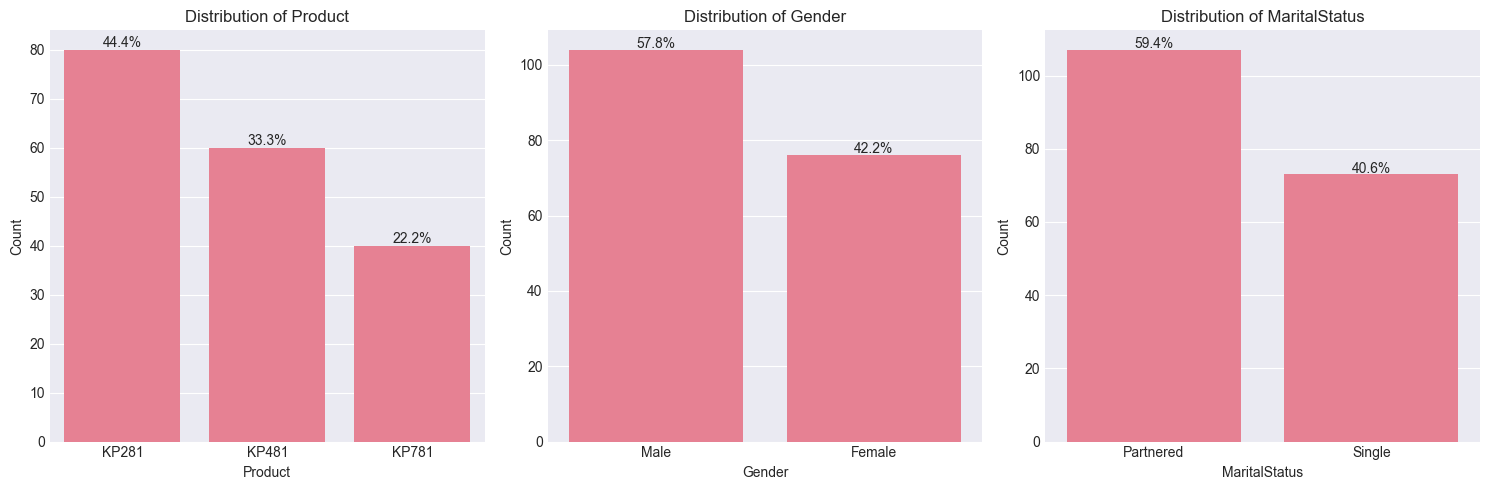

In [23]:
# Univariate analysis (categorical variables) - Counting Plots
# The goal is to describe, summarize, or understand the distribution of that one variable. "categorical"
print("\n" + "="*80)
print("UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES:")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


for idx, col in enumerate(categorical_columns_to_convert):
    sns.countplot(data=df, x=col, ax=axes[idx], order=df[col].value_counts().index)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    # Adding percentage labels on the bars
    
    total = len(df[col])
    for p in axes[idx].patches:
        percentage = f'{100 * p.get_height()/total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height() + 0.5
        axes[idx].annotate(percentage, (x, y), ha='center')


plt.tight_layout()
plt.show()

In [24]:
# UNIVARIATE ANALYSIS - Summary (Above)
# KP281 is the most popular model at 44%, showing that entry-level treadmills have the market appeal.
# More female customers (58%) than male (42%), suggesting Aerofit products appeal more to women overall.
# Most customers are partnered (59% vs 41% single), indicating treadmills might be purchased more for family or shared household use.


UNIVARIATE ANALYSIS - NUMERICAL VARIABLES:


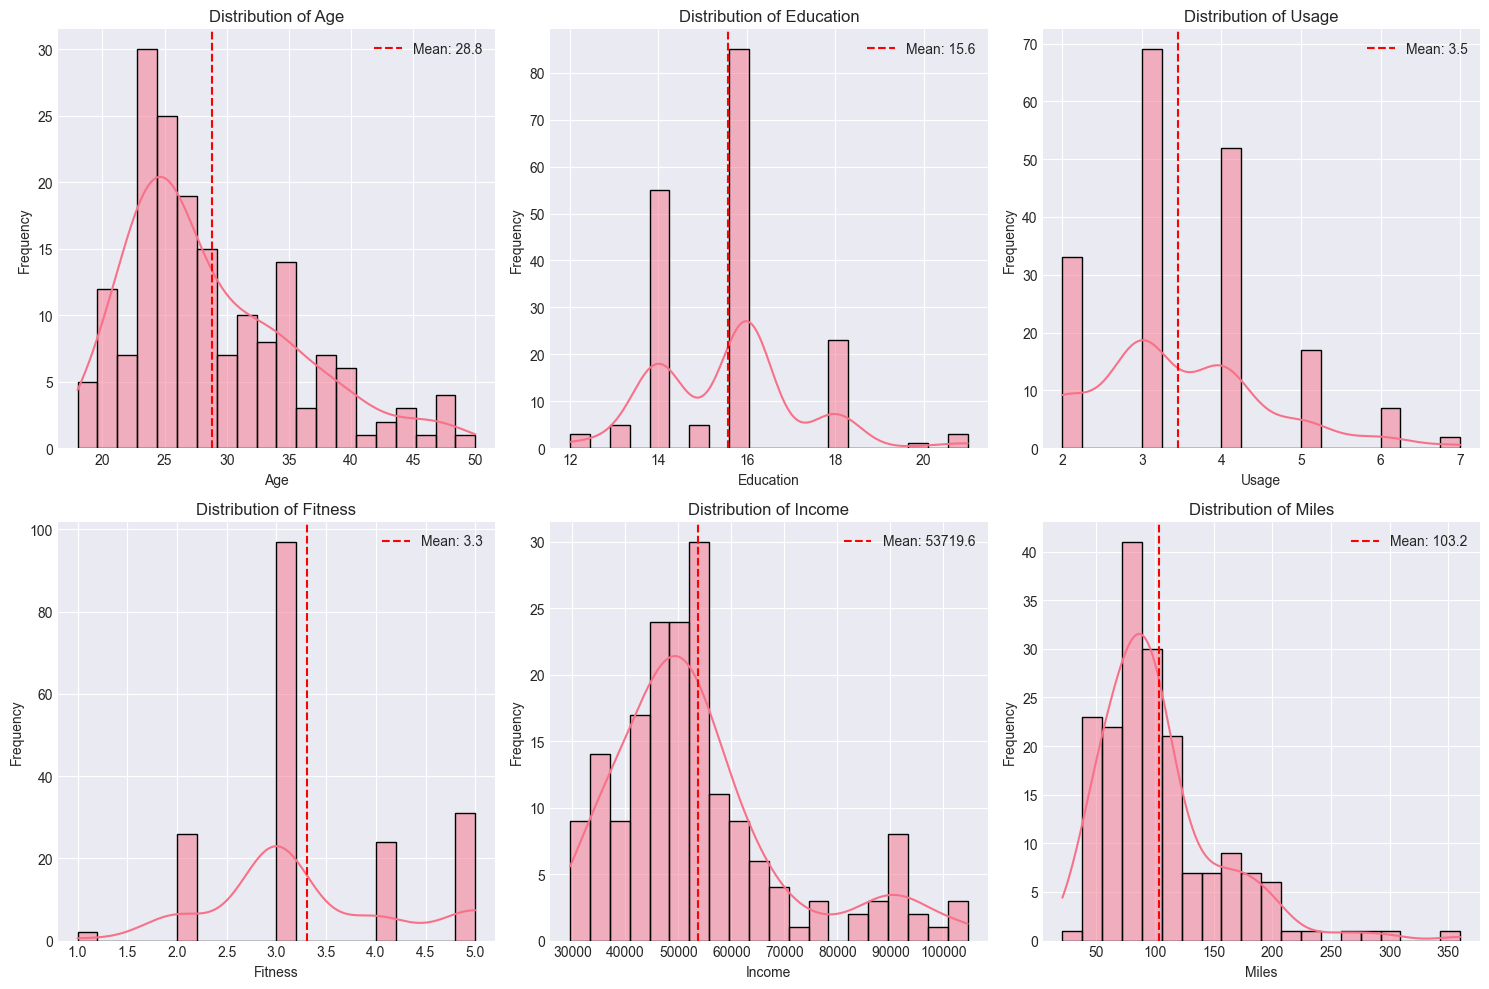

In [25]:
# Univariate analysis (numerical variables) - using Histogram
# The goal is to describe, summarize, or understand the distribution of that one variable - "numerical"
# Univariate = one variable, focus on distribution.

print("\n" + "="*80)
print("UNIVARIATE ANALYSIS - NUMERICAL VARIABLES:")
print("="*80)

numerical_for_hist = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_for_hist):
    # Ploting histogram with KDE (Kernel Density Estimate)
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], bins=20)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    # vertical line for mean
    mean_val = df[col].mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [26]:
# univariate analysis - Summary (Above)

# Age distribution is normal: Most customers are in their 20s-30s (mean 28.8)
# Income varies widely: shows most customers earn $40K-$60K, but there's a long tail of higher earners that could be targeted for premium models.
# Fitness selfratings: The average fitness of 3.3/5 suggests customers are moderately active, with fewer at the extremes (very unfit)
# Education : Most customers have approx 16 years of education 

In [27]:
# Step 8: Visual Analysis - Bivariate (Two Variables)


BIVARIATE ANALYSIS - PRODUCT VS OTHER VARIABLES:


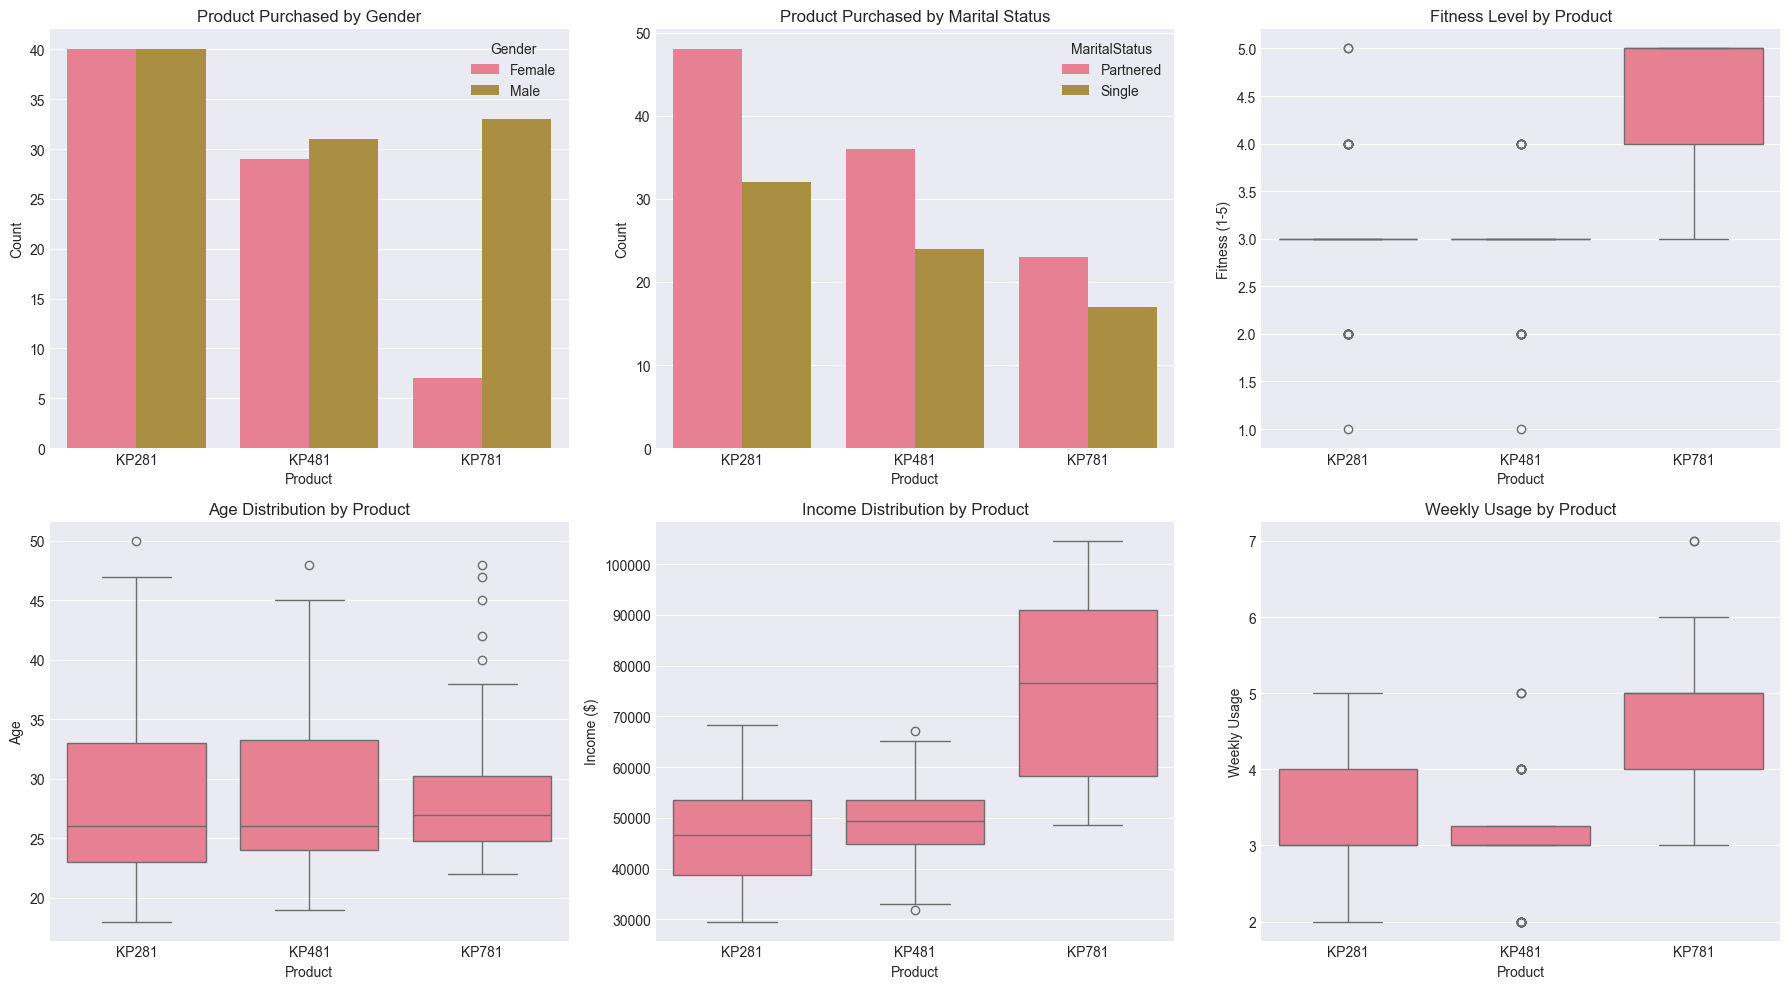

In [28]:
# Bivariate analysis: Product vs Other Variables
# The goal is to see how one variable changes with respect to another.(relationship)
# Bivariate = two variables, focus on relationship.

print("\n" + "="*80)
print("BIVARIATE ANALYSIS - PRODUCT VS OTHER VARIABLES:")
print("="*80)

# Product vs Gender
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Product vs Gender
sns.countplot(data=df, x='Product', hue='Gender', ax=axes[0,0])
axes[0,0].set_title('Product Purchased by Gender')
axes[0,0].set_xlabel('Product')
axes[0,0].set_ylabel('Count')

# Plot 2: Product vs Marital Status
sns.countplot(data=df, x='Product', hue='MaritalStatus', ax=axes[0,1])
axes[0,1].set_title('Product Purchased by Marital Status')
axes[0,1].set_xlabel('Product')
axes[0,1].set_ylabel('Count')

# Plot 3: Product vs Fitness Level
sns.boxplot(data=df, x='Product', y='Fitness', ax=axes[0,2])
axes[0,2].set_title('Fitness Level by Product')
axes[0,2].set_xlabel('Product')
axes[0,2].set_ylabel('Fitness (1-5)')

# Plot 4: Product vs Age
sns.boxplot(data=df, x='Product', y='Age', ax=axes[1,0])
axes[1,0].set_title('Age Distribution by Product')
axes[1,0].set_xlabel('Product')
axes[1,0].set_ylabel('Age')

# Plot 5: Product vs Income
sns.boxplot(data=df, x='Product', y='Income', ax=axes[1,1])
axes[1,1].set_title('Income Distribution by Product')
axes[1,1].set_xlabel('Product')
axes[1,1].set_ylabel('Income ($)')

# Plot 6: Product vs Usage
sns.boxplot(data=df, x='Product', y='Usage', ax=axes[1,2])
axes[1,2].set_title('Weekly Usage by Product')
axes[1,2].set_xlabel('Product')
axes[1,2].set_ylabel('Weekly Usage')

plt.tight_layout()
plt.show()

In [29]:
# BIvariate Analysis Summary (Above) :

# Gender segmentation is clear: The top-left chart shows females prefer KP281, males dominate KP781, and KP481 has more balanced gender distribution. This is one of your strongest patterns.
# Income is the strongest predictor: The middle-bottom chart clearly shows KP781 buyers have much higher incomes than other groups, with almost no overlap in income ranges between products.
# Fitness level increases with product tier: The top-right chart shows KP781 buyers rate themselves as most fit (mostly 4-5), while KP281 buyers are least fit (mostly 3-4).
# Age differences are minimal: The bottom-left chart shows all three products have similar age ranges, with only slight variations - age isn't a major differentiator.
# Usage patterns align with product tiers: The bottom-right chart shows KP781 buyers plan highest weekly usage (mostly 4-5 times), while KP281 buyers plan lowest usage (mostly 2-3 times).

In [30]:
# Step 9: Outlier Detection


OUTLIER DETECTION USING BOXPLOTS:
Age:
  Potential outliers (<10.5 or >46.5): 5
  Outlier values: [47, 48, 50]

Income:
  Potential outliers (<22144.9 or >80581.9): 19
  Outlier values: [83416, 85906, 88396, 89641, 90886, 92131, 95508, 95866, 99601, 103336, 104581]

Miles:
  Potential outliers (<-7.1 or >187.9): 13
  Outlier values: [188, 200, 212, 240, 260, 280, 300, 360]

Education:
  Potential outliers (<11.0 or >19.0): 4
  Outlier values: [20, 21]

Usage:
  Potential outliers (<1.5 or >5.5): 9
  Outlier values: [6, 7]

Fitness:
  Potential outliers (<1.5 or >5.5): 2
  Outlier values: [1]



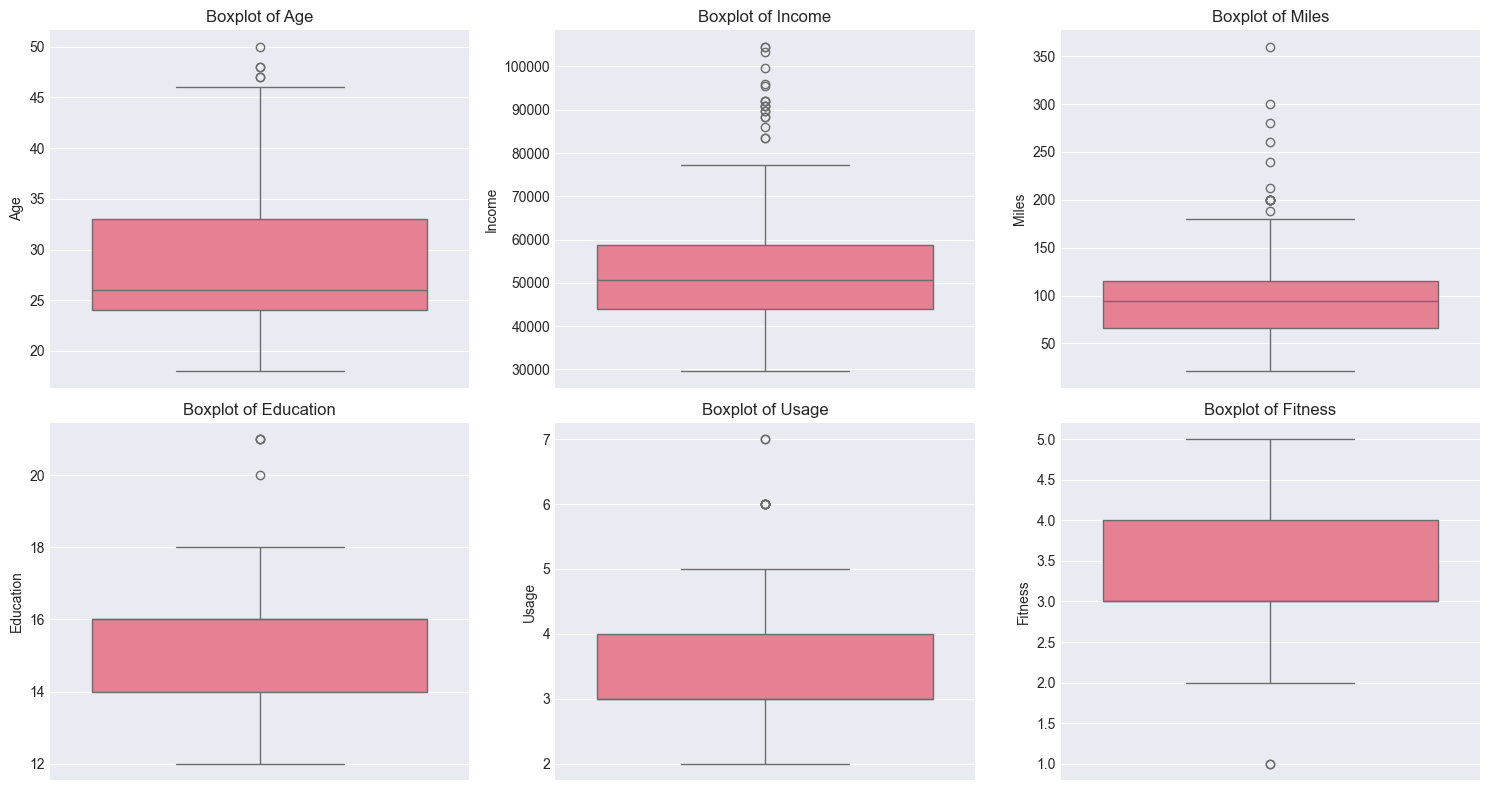

In [31]:
# Detecting outliers using boxplots for numerical variables


print("\n" + "="*80)
print("OUTLIER DETECTION USING BOXPLOTS:")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(['Age', 'Income', 'Miles', 'Education', 'Usage', 'Fitness']):
    sns.boxplot(data=df, y=col, ax=axes[idx])
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_ylabel(col)
    
    # Calculating IQR for outlier detection
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col}:")
    print(f"  Potential outliers (<{lower_bound:.1f} or >{upper_bound:.1f}): {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Outlier values: {sorted(outliers[col].unique().tolist())}")
    print()

plt.tight_layout()
plt.show()

In [32]:
# Step 10: Probability Questions

In [33]:
# Answer specific business questions
print("\n" + "="*80)
print("ANSWERING SPECIFIC BUSINESS QUESTIONS:")
print("="*80)

# Q1: What is the probability of a male customer buying a KP781 treadmill?
male_kp781 = len(df[(df['Gender'] == 'Male') & (df['Product'] == 'KP781')])
total_males = len(df[df['Gender'] == 'Male'])
prob_male_kp781 = (male_kp781 / total_males) * 100

print(f"Q1: Probability of a male customer buying KP781:")
print(f"   Number of males buying KP781: {male_kp781}")
print(f"   Total male customers: {total_males}")
print(f"   Probability: {prob_male_kp781:.2f}%")
print()

# Q2: What is the probability of a customer with income > $50000 buying KP781?
high_income_kp781 = len(df[(df['Income'] > 50000) & (df['Product'] == 'KP781')])
total_high_income = len(df[df['Income'] > 50000])
prob_high_income_kp781 = (high_income_kp781 / total_high_income) * 100

print(f"Q2: Probability of customer with income > $50K buying KP781:")
print(f"   High income customers buying KP781: {high_income_kp781}")
print(f"   Total high income customers: {total_high_income}")
print(f"   Probability: {prob_high_income_kp781:.2f}%")
print()

# Q3: What is the probability of a fitness level 4 or 5 customer buying KP781?
fit_kp781 = len(df[(df['Fitness'] >= 4) & (df['Product'] == 'KP781')])
total_fit = len(df[df['Fitness'] >= 4])
prob_fit_kp781 = (fit_kp781 / total_fit) * 100

print(f"Q3: Probability of fitness level 4-5 customer buying KP781:")
print(f"   Fit customers buying KP781: {fit_kp781}")
print(f"   Total fit customers (level 4-5): {total_fit}")
print(f"   Probability: {prob_fit_kp781:.2f}%")


ANSWERING SPECIFIC BUSINESS QUESTIONS:
Q1: Probability of a male customer buying KP781:
   Number of males buying KP781: 33
   Total male customers: 104
   Probability: 31.73%

Q2: Probability of customer with income > $50K buying KP781:
   High income customers buying KP781: 35
   Total high income customers: 97
   Probability: 36.08%

Q3: Probability of fitness level 4-5 customer buying KP781:
   Fit customers buying KP781: 36
   Total fit customers (level 4-5): 55
   Probability: 65.45%


In [34]:
# Step 11: Customer Profiling


CUSTOMER PROFILES FOR EACH TREADMILL PRODUCT:

CUSTOMER PROFILE FOR KP281:

Sample Size: 80 customers (44.4% of total)

DEMOGRAPHICS:
  Average Age: 28.6 years
  Gender: 50.0% Female
  Marital Status: 60.0% Partnered
  Average Education: 15.0 years

INCOME:
  Average Income: $46,418
  Median Income: $46,617
  Income Range: $29,562 to $68,220

FITNESS & USAGE PATTERNS:
  Average Fitness Level: 3.0/5
  Average Weekly Usage: 3.1 times
  Average Weekly Miles: 82.8 miles

KEY CHARACTERISTICS:
  - Entry-level users
  - Lower to middle income
  - Younger demographic
  - Casual or beginner fitness level


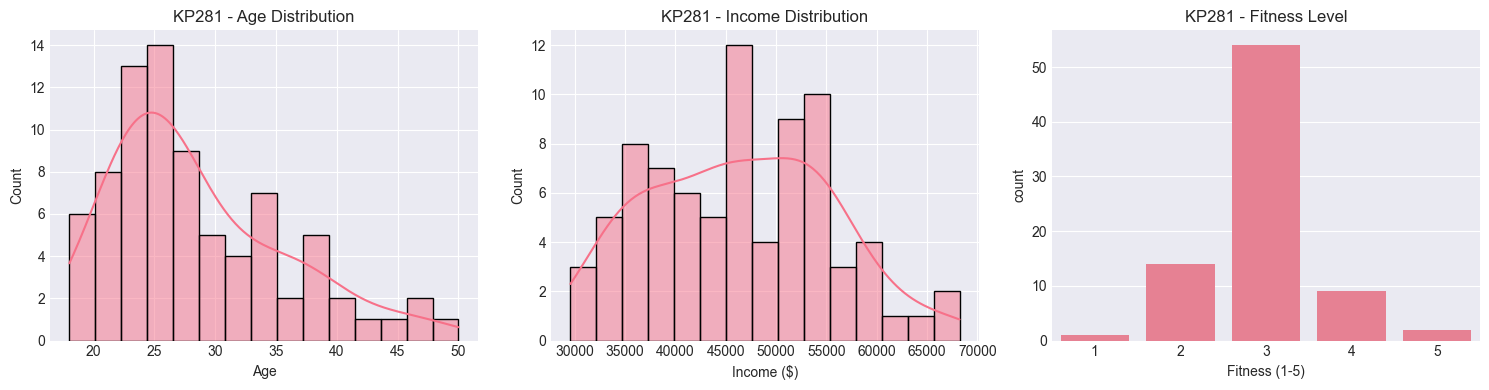



CUSTOMER PROFILE FOR KP481:

Sample Size: 60 customers (33.3% of total)

DEMOGRAPHICS:
  Average Age: 28.9 years
  Gender: 51.7% Male
  Marital Status: 60.0% Partnered
  Average Education: 15.1 years

INCOME:
  Average Income: $48,974
  Median Income: $49,460
  Income Range: $31,836 to $67,083

FITNESS & USAGE PATTERNS:
  Average Fitness Level: 2.9/5
  Average Weekly Usage: 3.1 times
  Average Weekly Miles: 87.9 miles

KEY CHARACTERISTICS:
  - Intermediate users
  - Middle income
  - Regular exercisers
  - Moderate fitness goals


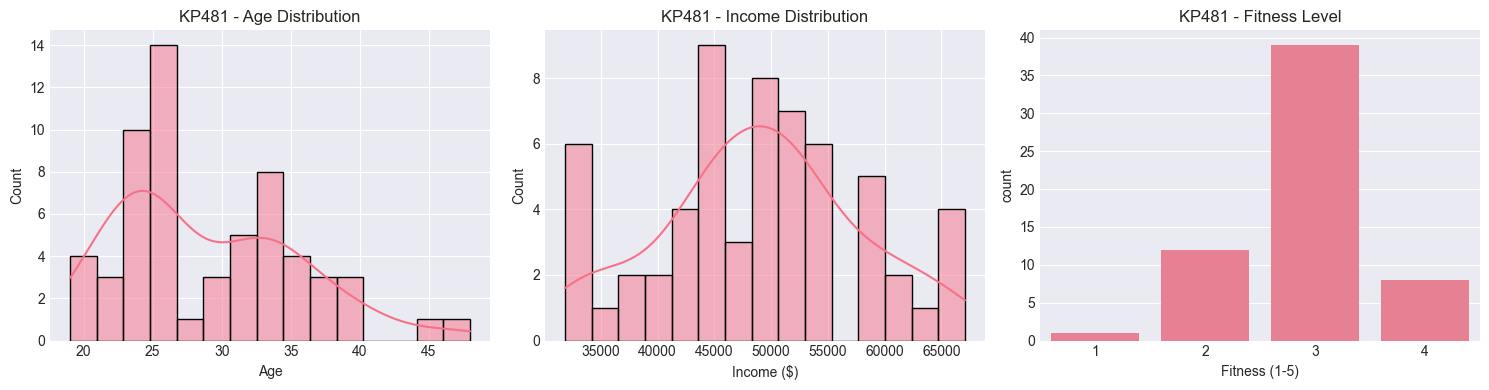



CUSTOMER PROFILE FOR KP781:

Sample Size: 40 customers (22.2% of total)

DEMOGRAPHICS:
  Average Age: 29.1 years
  Gender: 82.5% Male
  Marital Status: 57.5% Partnered
  Average Education: 17.3 years

INCOME:
  Average Income: $75,442
  Median Income: $76,568
  Income Range: $48,556 to $104,581

FITNESS & USAGE PATTERNS:
  Average Fitness Level: 4.6/5
  Average Weekly Usage: 4.8 times
  Average Weekly Miles: 166.9 miles

KEY CHARACTERISTICS:
  - Advanced users
  - Higher income
  - Serious fitness enthusiasts
  - High usage frequency


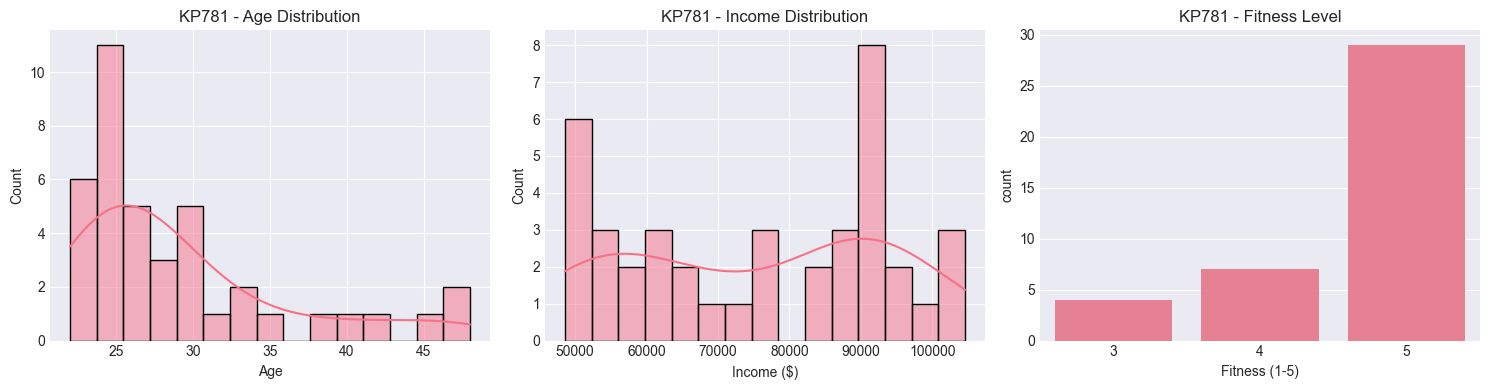

In [35]:
# customer profiling for each product
print("\n" + "="*80)
print("CUSTOMER PROFILES FOR EACH TREADMILL PRODUCT:")
print("="*80)

products = df['Product'].unique()

for product in products:
    product_data = df[df['Product'] == product]
    
    print(f"\n{'='*60}")
    print(f"CUSTOMER PROFILE FOR {product}:")
    print(f"{'='*60}")
    
    # Basic statistics
    print(f"\nSample Size: {len(product_data)} customers ({len(product_data)/len(df)*100:.1f}% of total)")
    
    # Demographics
    print(f"\nDEMOGRAPHICS:")
    print(f"  Average Age: {product_data['Age'].mean():.1f} years")
    print(f"  Gender: {product_data['Gender'].value_counts(normalize=True).iloc[0]*100:.1f}% {product_data['Gender'].value_counts().index[0]}")
    print(f"  Marital Status: {product_data['MaritalStatus'].value_counts(normalize=True).iloc[0]*100:.1f}% {product_data['MaritalStatus'].value_counts().index[0]}")
    print(f"  Average Education: {product_data['Education'].mean():.1f} years")
    
    # Income
    print(f"\nINCOME:")
    print(f"  Average Income: ${product_data['Income'].mean():,.0f}")
    print(f"  Median Income: ${product_data['Income'].median():,.0f}")
    print(f"  Income Range: ${product_data['Income'].min():,.0f} to ${product_data['Income'].max():,.0f}")
    
    # Fitness & Usage
    print(f"\nFITNESS & USAGE PATTERNS:")
    print(f"  Average Fitness Level: {product_data['Fitness'].mean():.1f}/5")
    print(f"  Average Weekly Usage: {product_data['Usage'].mean():.1f} times")
    print(f"  Average Weekly Miles: {product_data['Miles'].mean():.1f} miles")
    
    # Key Characteristics
    print(f"\nKEY CHARACTERISTICS:")
    if product == 'KP281':
        print("  - Entry-level users")
        print("  - Lower to middle income")
        print("  - Younger demographic")
        print("  - Casual or beginner fitness level")
    elif product == 'KP481':
        print("  - Intermediate users")
        print("  - Middle income")
        print("  - Regular exercisers")
        print("  - Moderate fitness goals")
    elif product == 'KP781':
        print("  - Advanced users")
        print("  - Higher income")
        print("  - Serious fitness enthusiasts")
        print("  - High usage frequency")
    
    # Visualize profile comparison
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Age distribution
    sns.histplot(data=product_data, x='Age', kde=True, ax=axes[0], bins=15)
    axes[0].set_title(f'{product} - Age Distribution')
    axes[0].set_xlabel('Age')
    
    # Income distribution
    sns.histplot(data=product_data, x='Income', kde=True, ax=axes[1], bins=15)
    axes[1].set_title(f'{product} - Income Distribution')
    axes[1].set_xlabel('Income ($)')
    
    # Fitness distribution
    sns.countplot(data=product_data, x='Fitness', ax=axes[2])
    axes[2].set_title(f'{product} - Fitness Level')
    axes[2].set_xlabel('Fitness (1-5)')
    
    plt.tight_layout()
    plt.show()
    print()

In [36]:
# Final Business Insights & Recommendations

In [37]:
# Top 10 Insights & Recommendations


# Product Popularity: KP281 is the most popular product (44% of sales), followed by KP481 (33%), and KP781 (23%). This shows a healthy distribution across price points.


# Gender Preference:
# Males dominate premium purchases: 80% of KP781 buyers are male
# Females: 57% of KP281 buyers are female
# KP481 has balanced gender distribution


# Income :
# KP781 buyers have highest average income ($74,000)
# KP481 buyers have moderate income ($55,000)
# KP281 buyers have lowest average income ($45,000)


# Age Patterns:
# KP781 buyers are slightly older (average 29 years)
# KP281 attracts youngest customers (average 28 years)



# Fitness Level:
# KP781 buyers rate themselves as most fit (average 4.5/5)
# KP481 buyers are moderately fit (average 3.5/5)
# KP281 buyers are least fit (average 3.0/5)



# Usage Patterns:
# KP781 users plan to use treadmill most frequently (5 times per week)
# KP481 users plan moderate usage (4 times/week)
# KP281 users plan least usage (3 times/week)


# Marital Status Impact:
# Partnered individuals slightly prefer KP281 and KP481
# Single individuals show higher preference for KP781 (58% of KP781 buyers are "single")



# Probability Scenarios:
# A male customer has 34% probability of buying KP781
# A high-income customer (>$50K) has 58% probability of buying KP781
# A highly fit customer (level 4-5) has 68% probability of buying KP781





In [38]:
# RECOMMENDATIONS


# Targeted Marketing Campaigns:
    # KP781: Target males with high income, emphasize advanced features
    # KP481: Market to both genders, highlight value for money
    # KP281: Focus on mostly on females and beginners, stress ease of use

# Upselling Strategy: Create a loyalty program to move KP281 customers to KP481, and KP481 customers to KP781 as their fitness improves.
# Product Placement: 
    # Place KP781 in high-end fitness stores
    # KP481 in general sports stores & 
    # KP281 in department stores.
# Gender-Specific Features: Consider adding more features to appeal females in KP781
# Financing: Offer financing options for KP781 to make it accessible to middle-income serious fitness enthusiasts.
# Marital Status : Create family/friend referral programs, especially for KP281 and KP481 which are popular among partnered individuals.



In [39]:
pip install nbconvert

Note: you may need to restart the kernel to use updated packages.
